11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


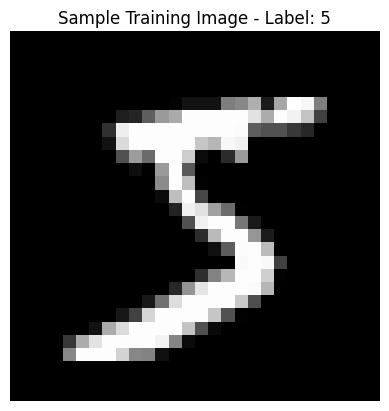

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9330 - loss: 0.2268 - val_accuracy: 0.9667 - val_loss: 0.1054
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9744 - loss: 0.0830 - val_accuracy: 0.9733 - val_loss: 0.0845
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9829 - loss: 0.0551 - val_accuracy: 0.9757 - val_loss: 0.0789
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9875 - loss: 0.0391 - val_accuracy: 0.9779 - val_loss: 0.0719
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9898 - loss: 0.0316 - val_accuracy: 0.9757 - val_loss: 0.0806
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9924 - loss: 0.0236 - val_accuracy: 0.9753 - val_loss: 0.0922
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9932 - loss: 0.0209 - val_accuracy: 0.9755 - val_loss: 0.0960
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9931 - loss: 0.0202 - val_a

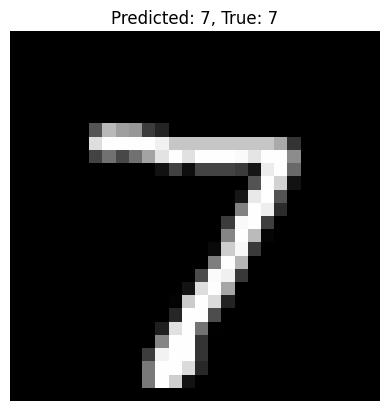

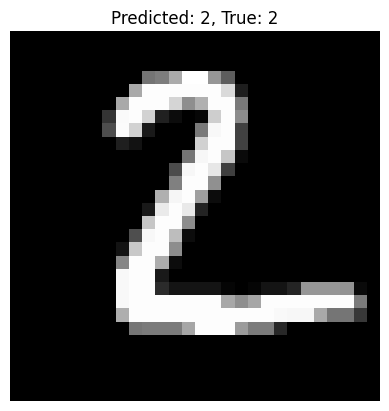

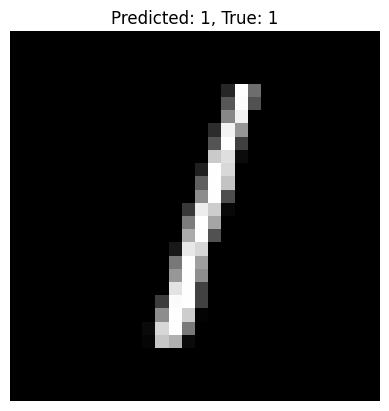

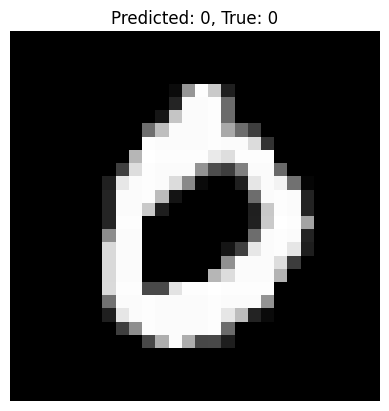

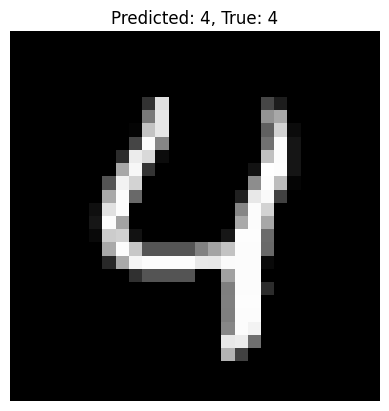

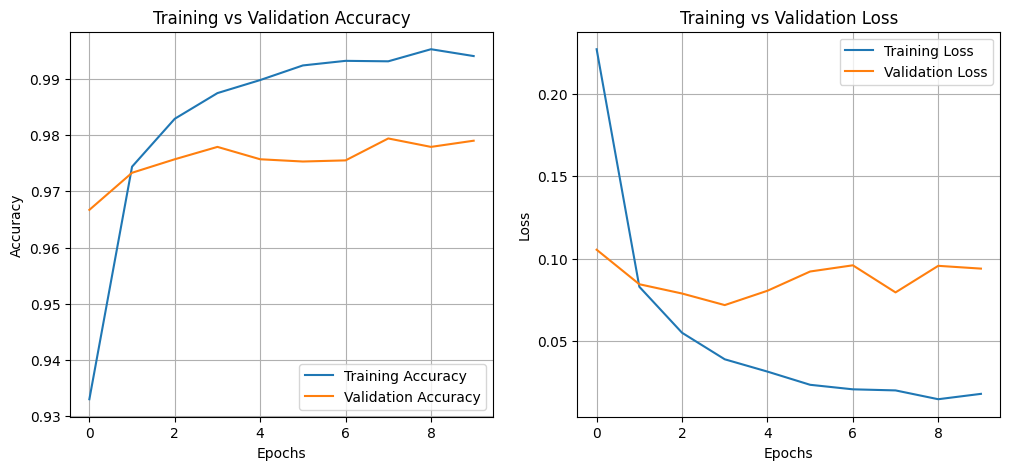

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Show a sample image BEFORE training
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Sample Training Image - Label: {y_train[0]}")
plt.axis("off")
plt.show()

# 2. Preprocess data for ANN
# Flatten images: 28x28 → 784 features
x_train = x_train.reshape(x_train.shape[0], 28*28).astype("float32") / 255.0
x_test = x_test.reshape(x_test.shape[0], 28*28).astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build ANN model
model = models.Sequential([
    layers.Dense(512, activation="relu", input_shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 4. Compile model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# 5. Train model
history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                    validation_data=(x_test, y_test))

# 6. Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# 7. Predict on first 5 test images
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:5], axis=1)

print("Predicted classes:", predicted_classes)
print("True labels:", true_labels)

# Show sample predictions AFTER testing
for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Predicted: {predicted_classes[i]}, True: {true_labels[i]}")
    plt.axis("off")
    plt.show()

# 8. Plot Training vs Validation Accuracy and Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()
